### 🧠 What is Query Planning and Decomposition?
Query Planning and Decomposition is a technique where a complex user query is broken down into simpler sub-questions or tasks, allowing a system (like a RAG agent) to:

- Understand the question more deeply
- Retrieve more precise and complete information
- Execute step-by-step reasoning

It's like reverse-engineering a question into manageable steps before answering.

🧠 What's New in This Version?
- ✅ Add a Query Planner Node
- ✅ Break complex user queries into sub-questions
- ✅ Retrieve docs per sub-question
- ✅ Combine all retrieved contexts
- ✅ Generate a final consolidated answer

In [9]:
import os
from typing import List
from pydantic import BaseModel
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader, WebBaseLoader
from langgraph.graph import StateGraph, END

In [10]:
import os
from langfuse.langchain import CallbackHandler
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

load_dotenv()
langfuse_trace = CallbackHandler()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

llm=init_chat_model("openai:gpt-4o-mini")
llm_ollama = init_chat_model(
    model="granite4",
    model_provider="ollama"
)

In [11]:
# ----------------------------
# 1. Load and Embed Documents
# ----------------------------
from langchain_ollama import OllamaEmbeddings


urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]
docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

# embedding = OpenAIEmbeddings()
embedding = OllamaEmbeddings(model="nomic-embed-text")
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()


In [12]:
# ----------------------------
# 2. State Schema
# ----------------------------
class RAGState(BaseModel):
    question: str
    sub_questions: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [13]:
# ----------------------------
# 3. Nodes
# ----------------------------

## a. Query Planner: splits input question
def plan_query(state: RAGState) -> RAGState:
   
    prompt = f"""
Break the following complex question into 2-3 sub-questions:

Question: {state.question}

Sub-questions:
"""
    result = llm.invoke(prompt, config={"callbacks": [langfuse_trace]})
    sub_questions = [line.strip("- ").strip() for line in result.content.strip().split("\n") if line.strip()]
    print("sub_questions: ", sub_questions)
    return RAGState(question=state.question, sub_questions=sub_questions)

## b. Retrieve documents for each sub-question
def retrieve_for_each(state: RAGState) -> RAGState:
    all_docs = []
    for sub in state.sub_questions:
        docs = retriever.invoke(sub, config={"callbacks": [langfuse_trace]})
        all_docs.extend(docs)
    return RAGState(question=state.question, sub_questions=state.sub_questions, retrieved_docs=all_docs)

## c. Generate final answer
def generate_final_answer(state: RAGState) -> RAGState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
Use the context below to answer the question.

Context:
{context}

Question: {state.question}
"""
    
    answer = llm_ollama.invoke(prompt, config={"callbacks": [langfuse_trace]}).content
    return RAGState(
        question=state.question,
        sub_questions=state.sub_questions,
        retrieved_docs=state.retrieved_docs,
        answer=answer,
    )


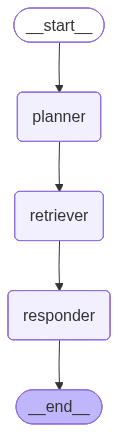

In [14]:
# ----------------------------
# 4. Build LangGraph
# ----------------------------
builder = StateGraph(RAGState)

builder.add_node("planner", plan_query)
builder.add_node("retriever", retrieve_for_each)
builder.add_node("responder", generate_final_answer)

builder.set_entry_point("planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

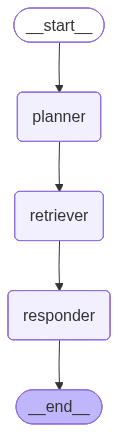

In [15]:
graph

In [16]:
# ----------------------------
# 5. Run the pipeline
# ----------------------------
if __name__ == "__main__":
    user_query = "Explain how agent loops work and what are the challenges in diffusion video generation?"
    initial_state = RAGState(question=user_query)
    final_state = graph.invoke(initial_state, config={"callbacks": [langfuse_trace]})
    print(final_state)

    print("\n🔍 Sub-questions:")
    for q in final_state['sub_questions']:
        print("-", q)

    print("\n✅ Final Answer:\n", final_state['answer'])

sub_questions:  ['1. What are the key components and processes involved in the functioning of agent loops in the context of video generation?', '2. What specific challenges are encountered when implementing diffusion techniques in video generation processes?', '3. How do agent loops interact with diffusion models to influence the quality and efficiency of video generation?']
{'question': 'Explain how agent loops work and what are the challenges in diffusion video generation?', 'sub_questions': ['1. What are the key components and processes involved in the functioning of agent loops in the context of video generation?', '2. What specific challenges are encountered when implementing diffusion techniques in video generation processes?', '3. How do agent loops interact with diffusion models to influence the quality and efficiency of video generation?'], 'retrieved_docs': [Document(id='9d849209-dc4f-4201-aa03-a23b91b370eb', metadata={'source': 'https://lilianweng.github.io/posts/2024-04-12-